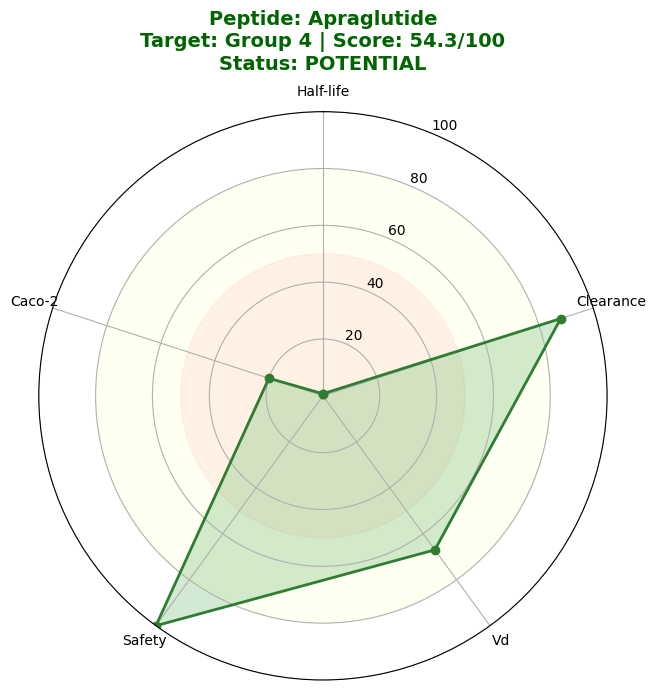

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class PeptiDrugPhAI:
    def __init__(self):

        self.target_hl_map = {
            1: 1, # antimicrobial and antifungal peptides
            2: 2, # chronic therapy/hormone regulators
            3: 0, # acute resuscitation/vasoactive drugs
            4: 1, # CNS-acting/analgesic drugs
            5: 0  #
        }

    def _calculate_scores(self, hl_logits, cl_prob, vd_prob, target_id, tox_class, caco2_class):

        # 1. Half-life Score
        exp_l = np.exp(hl_logits - np.max(hl_logits))
        hl_probs = exp_l / exp_l.sum()

        #
        target_idx = self.target_hl_map.get(target_id, 1)
        s_hl = hl_probs[target_idx] * 100

        # 2. Clearance Score

        if target_id == 3:
            s_cl = cl_prob * 100
        else:
            s_cl = (1 - cl_prob) * 100

        # 3. Vd Score
        #
        if target_id in [1, 4]:
            s_vd = vd_prob * 100
        else:
            s_vd = (1 - vd_prob) * 100

        # 4. Safety & Permeability
        s_tox = 0 if tox_class == 1 else 100
        s_caco = 100 if caco2_class == 1 else 20

        scores = [s_hl, s_cl, s_vd, s_tox, s_caco]
        labels = ['Half-life', 'Clearance', 'Vd', 'Safety', 'Caco-2']

        #
        weights = [0.30, 0.25, 0.15, 0.20, 0.10]

        final_score = sum(s * w for s, w in zip(scores, weights))
        return scores, labels, final_score

    def evaluate(self, name, hl_logits, cl_prob, vd_prob, target_id, tox_class=0, caco2_class=0, save_path=None):

        scores, labels, total = self._calculate_scores(hl_logits, cl_prob, vd_prob, target_id, tox_class, caco2_class)

        # ---(Radar Chart) ---
        num_vars = len(labels)
        angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
        scores_plot = scores + [scores[0]]
        angles += angles[:1]

        fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))


        ax.fill(np.linspace(0, 2*np.pi, 100), [50]*100, color='red', alpha=0.05)
        ax.fill(np.linspace(0, 2*np.pi, 100), [80]*100, color='yellow', alpha=0.05)

        ax.plot(angles, scores_plot, color='#2E7D32', linewidth=2, marker='o')
        ax.fill(angles, scores_plot, color='#4CAF50', alpha=0.25)

        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        ax.set_thetagrids(np.degrees(angles[:-1]), labels)
        ax.set_ylim(0, 100)


        status = "IDEAL CANDIDATE" if total > 80 else "POTENTIAL"
        if tox_class == 1: status = "TOXICITY ALERT"

        plt.title(f"Peptide: {name}\nTarget: Group {target_id} | Score: {total:.1f}/100\nStatus: {status}",
                  size=14, pad=30, fontweight='bold', color='darkgreen' if tox_class==0 else 'red')

        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=300)
        plt.show()

        return total

# --- Test ---
evaluator = PeptiDrugPhAI()


score = evaluator.evaluate(
    name="Apraglutide",
    hl_logits=[-1.57, -1.87, 3.03],
    cl_prob=0.12,
    vd_prob=0.67,
    target_id=4,
    tox_class=0,
    caco2_class=0
)

